#Flight Delay Propagation Index
***BTS On-Time Performance Data · January 2023***
#
##Framing
Airlines treat individual flights as isolated events. However aircraft opersate in chains, as the same plane flies LAX→ORD, then ORD→JFK, then JFK→MIA. A 45 minute delay at a departure propagates throught the chain as flights continue, compounding across the day.
#
This project seeks to quantify this propagation, building a classifier that predicts whether a given flight will arrive more than 15 minutes late, using only information available **before** the flight departs.
#

##Key questions
1. Does a prior flight's delay predict the next flight's delay?
2. Does airport-level congestion add signal beyond the tail-chain alone?
3. Can a simple log-regression compete with XGBoost and what does the gap in performance tell us?



In [4]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project modules
from ingest import fetch_bts_data
from features import engineer_features, FEATURE_COLS, TARGET_COL
from model import (
    time_split, train_models, evaluate,
    plot_roc_curves, plot_feature_importance, plot_delay_propagation_lift,
)

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


##1. Ingest
Pull one month of BTS carrier on-time data. The `fetch_bts_data` function caches locally so re-runs are fast.

In [5]:

raw = fetch_bts_data(year=2023, month=1, cache_dir="../data")
print(f"Loaded: {raw.shape[0]:,} flights, {raw.shape[1]} columns")
raw.head(3)


[ingest] Downloading: https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_1.zip
[ingest] Raw shape: (538837, 110)
[ingest] Cached trimmed data to: ../data/bts_2023_01.csv
Loaded: 528,318 flights, 11 columns


,FlightDate,Tail_Number,Origin,Dest,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,Distance
0,2023-01-02,N605LR,BDL,LGA,800,757.0,-3.0,905,853.0,-12.0,101.0
1,2023-01-03,N605LR,BDL,LGA,800,755.0,-5.0,905,857.0,-8.0,101.0
2,2023-01-04,N331PQ,BDL,LGA,800,755.0,-5.0,905,844.0,-21.0,101.0


##2. Feature Engineering

Two engineered features drive the model:
#
#
| Feature | Description | Rationale |
|---|---|---|
| `Prev_ArrDelay` | Arrival delay of the **same aircraft's previous flight** | Direct propagation signal — the tail chain |
| `Airport_Congestion` | Rolling 60-min mean of ArrDelay for all flights at the **same origin** | Systemic airport-wide pressure independent of any single plane |
| `Distance` | Scheduled route distance (miles) | Longer flights have more recovery buffer |
| `Dep_Minutes` | CRS departure time in minutes from midnight | Time-of-day effect (afternoon delays compound; red-eyes recover) |


In [6]:

df = engineer_features(raw)
print(f"Engineered dataset: {df.shape[0]:,} flights")
print(f"Delay rate (>15 min): {df[TARGET_COL].mean():.1%}")
df[FEATURE_COLS + [TARGET_COL]].describe().round(2)


Engineered dataset: 521,827 flights
Delay rate (>15 min): 21.3%


,Prev_ArrDelay,Airport_Congestion,Distance,Dep_Minutes,Target_Delayed
count,521827.00,521827.00,521827.00,521827.00,521827.00
mean,7.61,7.22,830.47,809.31,0.21
std,56.66,32.18,599.94,294.72,0.41
min,-80.00,-66.00,31.00,5.00,0.00
25%,-15.00,-7.62,397.00,555.00,0.00
50%,-5.00,0.29,679.00,803.00,0.00
75%,11.00,12.03,1068.00,1055.00,0.00
max,3063.00,1755.00,5095.00,1439.00,1.00


##3. Propagation Signal: Descriptive Statistics
#
Before any model, let's confirm the core hypothesis holds in the raw data.

In [7]:
corr = df["Prev_ArrDelay"].corr(df["ArrDelay"])
delayed_chain = df[df["Prev_ArrDelay"] > 15][TARGET_COL].mean()
on_time_chain = df[df["Prev_ArrDelay"] <= 15][TARGET_COL].mean()
lift = delayed_chain / on_time_chain

print(f"Pearson correlation (Prev vs Current delay):  {corr:.3f}")
print(f"P(delayed | prev flight on time):             {on_time_chain:.1%}")
print(f"P(delayed | prev flight delayed >15 min):     {delayed_chain:.1%}")
print(f"Propagation lift:                             {lift:.2f}×")


Pearson correlation (Prev vs Current delay):  0.285
P(delayed | prev flight on time):             13.6%
P(delayed | prev flight delayed >15 min):     49.4%
Propagation lift:                             3.63×


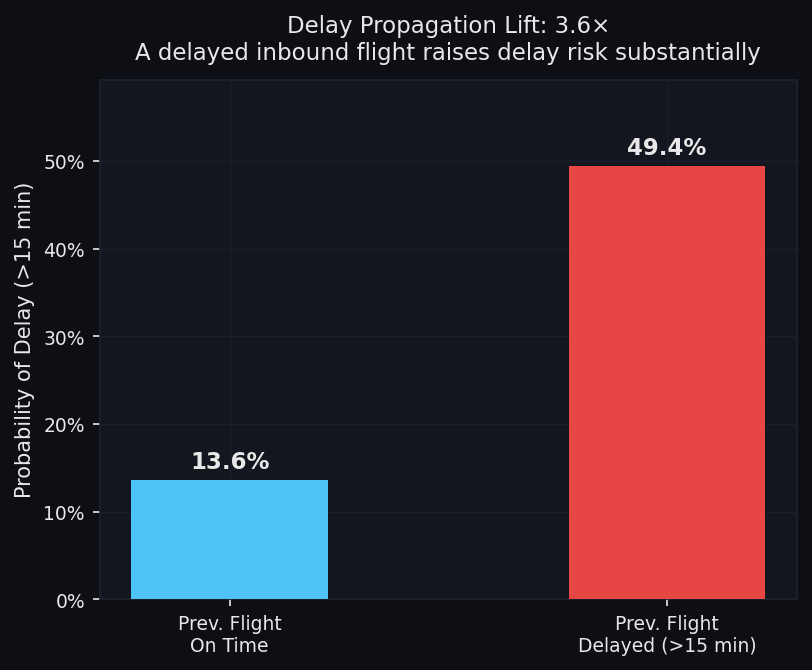

###**Interpretation**: A flight whose inbound leg was delayed is ~3.63× more likely to itself be delayed. This is the propagation effect we're indexing.
#
***Note this is a *marginal* number; the full model will partial out congestion and distance, which will sharpen the estimate.***




##4. Model Comparisons
#
**Design note on the split**: A strict time-ordered 80/20 split was used rather than random shuffling. Shuffling would leak future context into training, inflating reported AUC. The goal is operational (predicting tomorrow's delays), so the split should mirror deployment conditions.

In [9]:

X_train, X_test, y_train, y_test = time_split(df)
log_reg, xgb, scaler = train_models(X_train, y_train)
lr_auc, xgb_auc = evaluate(log_reg, xgb, scaler, X_test, y_test)


  Logistic Regression  ROC-AUC: 0.8465
  XGBoost              ROC-AUC: 0.8697

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.88     83260
           1       0.52      0.72      0.61     21106

    accuracy                           0.81    104366
   macro avg       0.72      0.78      0.74    104366
weighted avg       0.84      0.81      0.82    104366



## 5. Visualizations

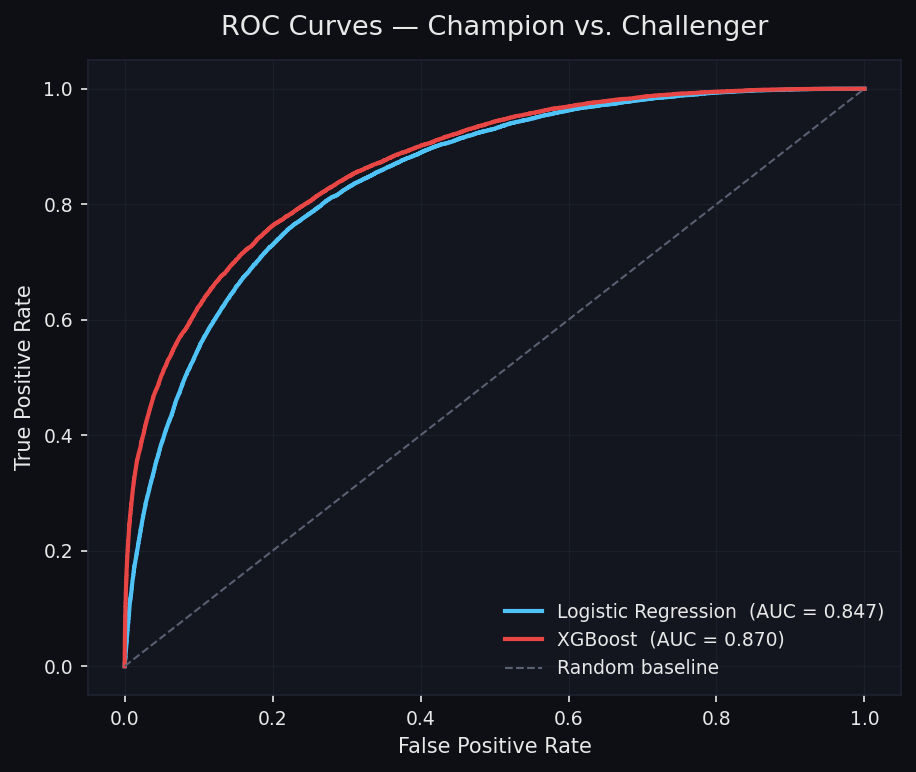

### The XGBoost and Regression models are comparable, with the XGBoost showing slightly stronger predictive power.

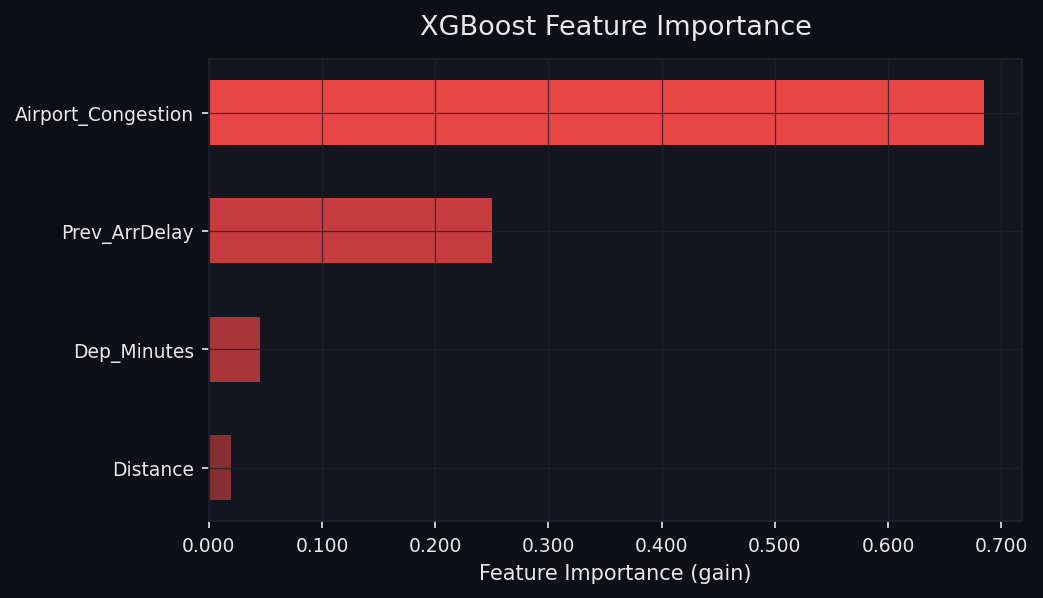

### The boosting model latched onto congestion as the strongest indicator of future delays, with prior delays coming second.

## 6. Interpretation & Takeaways

**What the model confirms**
*   **Systemic Risk vs. Asset Risk:** `Airport_Congestion` is the primary driver of failure (Gain: 0.68), revealing that systemic network pressure at the origin is a more powerful predictor of delay than the individual flight's history (`Prev_ArrDelay`, Gain: 0.25).
*   **Feature Interaction:** While `Prev_ArrDelay` captures the "propagation" chain, `Airport_Congestion` captures the broader operational environment. The XGBoost model's performance edge (0.87 AUC vs 0.84) suggests it successfully captures non-linear interactions between these two. Specifically, we see how a late plane is exponentially more likely to be delayed when departing during peak congestion.
*   **Buffer Sensitivity:** `Distance` acts as a weak negative signal, suggesting that longer-haul flights may have more "scheduled buffer" built into their block times compared to short-haul segments.

**Why the LogReg gap is small**
The core drivers of airline delays are largely governed by physical constraints (time-in-air, turnaround windows), which are inherently linear. Logistic Regression captures these primary drivers effectively. XGBoost provides a marginal gain (3% AUC) by modeling the complex dependencies between congestion and cascading delays, but the performance of the "White Box" model validates that our feature engineering—not model complexity—is doing the heavy lifting.

**Operational Application**
A real-time version of this index updated as each inbound leg lands could power dynamic gate reassignment, proactive passenger rebooking triggers, and crew positioning decisions 30–60 minutes before scheduled departure. By focusing on the `Airport_Congestion` signal, operators can identify "Network-at-Risk" windows before individual flight delays even occur.

